#LIBRARIES

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Data Integration

Workflow: The primary challenge is that the data is spread across five sheets in the given file. You must load all of them (netflix_titles, netflix_titles_cast, etc.) and merge them into a single master DataFrame using show_id as the key. Analytical Question: In a markdown cell, explain which type of join (e.g., inner, left, right, outer) you used to combine the main netflix_titles file with the others, and why this choice was the most appropriate for this task. Screenshot Requirement: Upload a single screenshot showing your merge code, the .info() output of the final merged DataFrame, and your markdown answer.

In [41]:
file = "/content/drive/MyDrive/EXAMINATION DOCS/Netflix.xlsx"

excel_file = pd.ExcelFile(file)

print(excel_file.sheet_names)


['netflix_titles', 'netflix_titles_directors', 'netflix_titles_countries', 'netflix_titles_cast', 'netflix_titles_category']


In [5]:
titles = pd.read_excel(file, sheet_name="netflix_titles")
cast = pd.read_excel(file, sheet_name="netflix_titles_cast")
country = pd.read_excel(file, sheet_name="netflix_titles_countries")
directors = pd.read_excel(file, sheet_name="netflix_titles_directors")
category = pd.read_excel(file, sheet_name="netflix_titles_category")

In [7]:
#Merging the dataset using left join; as the show_id matching records in other table
merged_df = titles.merge(cast, on="show_id", how="left")
merged_df = merged_df.merge(country, on="show_id", how="left")
merged_df = merged_df.merge(directors, on="show_id", how="left")
merged_df = merged_df.merge(category, on="show_id", how="left")

In [12]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139946 entries, 0 to 139945
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   duration_minutes  98561 non-null   object 
 1   duration_seasons  41387 non-null   object 
 2   type              139945 non-null  object 
 3   title             139945 non-null  object 
 4   date_added        139785 non-null  object 
 5   release_year      139944 non-null  float64
 6   rating            139870 non-null  object 
 7   description       139943 non-null  object 
 8   show_id           139942 non-null  float64
 9   cast              138456 non-null  object 
 10  country           134152 non-null  object 
 11  director          101031 non-null  object 
 12  listed_in         139942 non-null  object 
dtypes: float64(2), object(11)
memory usage: 13.9+ MB


In [10]:
merged_df.head()

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,cast,country,director,listed_in
0,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Alan Marriott,United States,Richard Finn,Children & Family Movies
1,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Alan Marriott,United States,Richard Finn,Comedies
2,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Alan Marriott,United States,Tim Maltby,Children & Family Movies
3,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Alan Marriott,United States,Tim Maltby,Comedies
4,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Alan Marriott,China,Richard Finn,Children & Family Movies


#Data Cleaning and Preprocessing
Workflow: Handle missing values in the combined dataset, especially in columns like date_added, director, and country. Convert date_added to a proper datetime format and extract the year_added for trend analysis. Analytical Question: In a markdown cell, describe your strategy for handling the missing country data. Did you fill it with a placeholder (like 'Unknown'), drop the rows, or use another method? Justify your choice. Screenshot Requirement: Upload a screenshot showing your code for handling missing values and creating the year_added column, along with your markdown answer.

In [48]:
merged_df.duplicated().sum()

np.int64(54)

not removing duplicates may be a chance of data loss as all columns are highly linked

In [15]:
merged_df.isnull().sum()

,0
duration_minutes,41385
duration_seasons,98559
type,1
title,1
date_added,161
release_year,2
rating,76
description,3
show_id,4
cast,1490


In [16]:
missing_percent = merged_df.isna().sum()/ len(merged_df)* 100

print(missing_percent)

duration_minutes    29.572121
duration_seasons    70.426450
type                 0.000715
title                0.000715
date_added           0.115044
release_year         0.001429
rating               0.054307
description          0.002144
show_id              0.002858
cast                 1.064696
country              4.140168
director            27.807154
listed_in            0.002858
dtype: float64


In [17]:
num_cols = merged_df.select_dtypes(include =["number"]).columns
cat_cols = merged_df.select_dtypes(include =["object"]).columns

In [18]:
num_cols

Index(['release_year', 'show_id'], dtype='object')

In [19]:
cat_cols

Index(['duration_minutes', 'duration_seasons', 'type', 'title', 'date_added',
       'rating', 'description', 'cast', 'country', 'director', 'listed_in'],
      dtype='object')

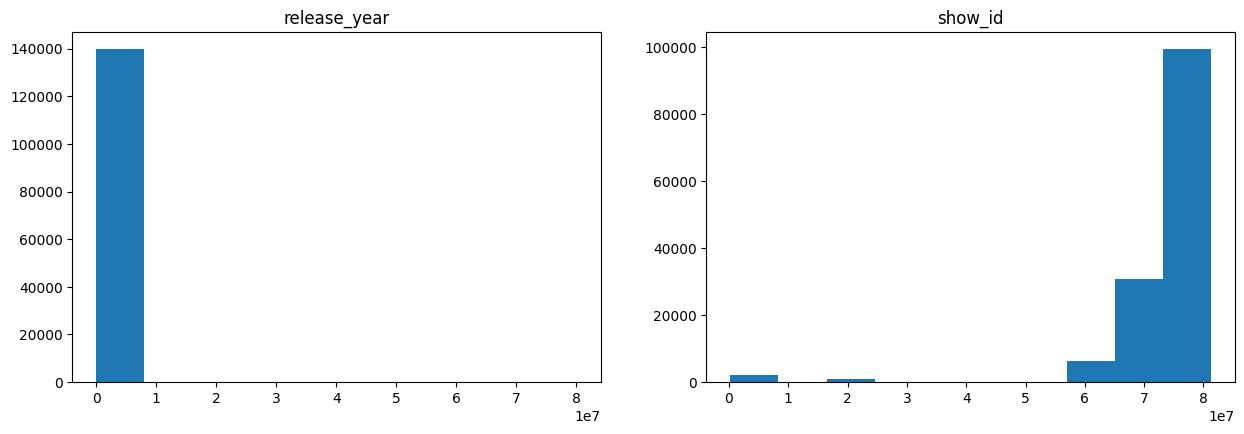

In [28]:
plt.figure(figsize=(15,10))
for i,col in enumerate(num_cols, 1):
  plt.subplot(2,2,i)
  plt.hist(merged_df[col])
  plt.title(col, fontsize=10)
  plt.title(col)

plt.show()

#Handle missing values

In [37]:


# 1. Country
merged_df["country"] = merged_df["country"].fillna("Unknown")

# 2. Director
merged_df["director"] = merged_df["director"].fillna("Unknown")

# 3. Date Added
merged_df["date_added"] = pd.to_datetime(merged_df["date_added"], errors="coerce")

# Remove rows where date_added is missing
merged_df = merged_df.dropna(subset=["date_added"])

# Create year_added column
merged_df["year_added"] = merged_df["date_added"].dt.year



In [38]:
merged_df.isnull().sum()

,0
duration_minutes,41227
duration_seasons,98557
type,0
title,0
date_added,0
release_year,0
rating,72
description,0
show_id,1
cast,1486


Handled missing values in the country column by replacing them with the placeholder value "Unknown".

- The country information is useful for analysis and visualization.Dropping rows would unnecessarily reduce the dataset and may remove valid Netflix titles.
- Filling with "Unknown" preserves all records
- This approach is suitable for exploratory data analysis because it avoids data loss and allows missing values to be identified separately during analysis.

Therefore, replacing missing country values with "Unknown" was the most appropriate preprocessing strategy.

In [45]:
#Numerical features were imputed using mode to reduce the effect of outliers
merged_df['duration_minutes'].fillna(
    merged_df['duration_minutes'].mode()[0],
    inplace=True
)

In [46]:
merged_df['duration_seasons'].fillna(
    merged_df['duration_seasons'].mode()[0],
    inplace=True
)
#Rating will handle on encoding

#EDA

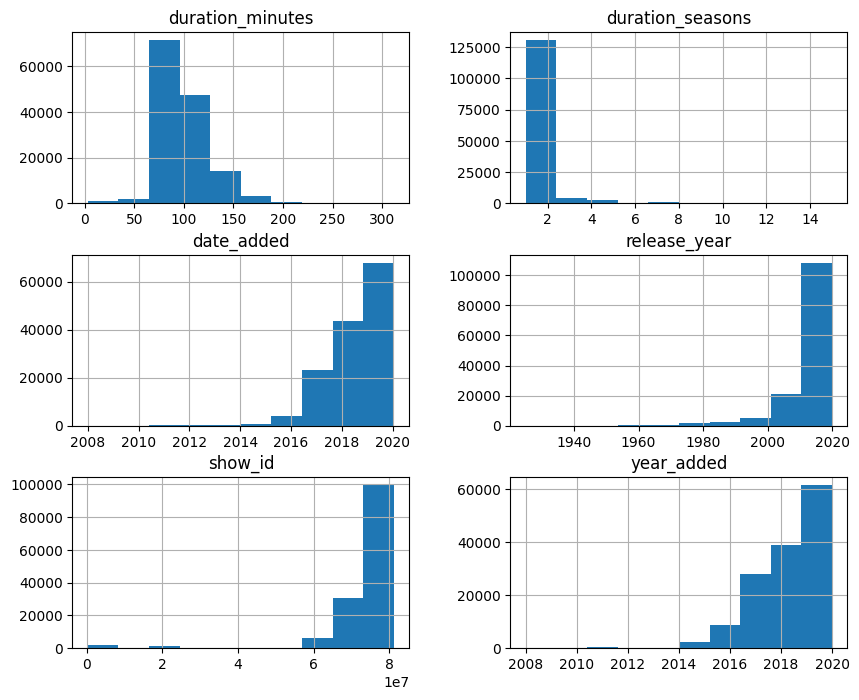

In [49]:
merged_df.hist(figsize=(10,8))
plt.show()

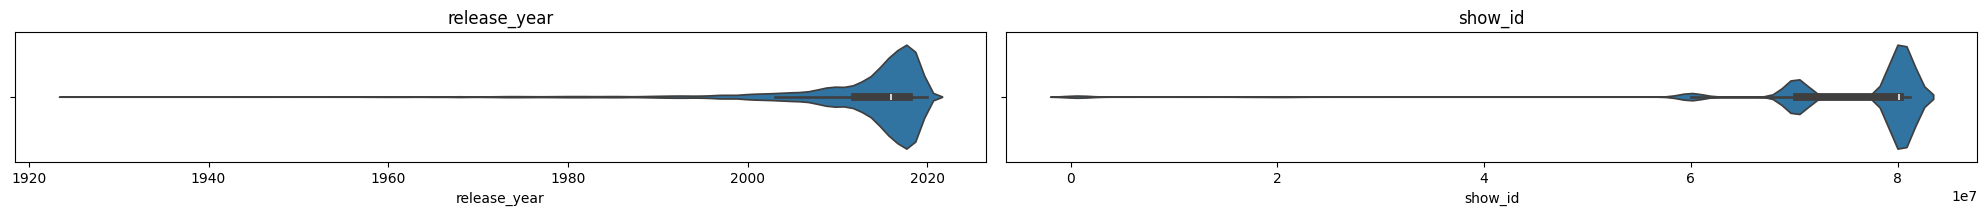

In [50]:
plt.figure(figsize=(20,15))

for i, col in enumerate(num_cols, 1):

    plt.subplot(8, 2, i)

    sns.violinplot(
        x= merged_df[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

##Handling Outliers

In [52]:
num_cols

Index(['release_year', 'show_id'], dtype='object')

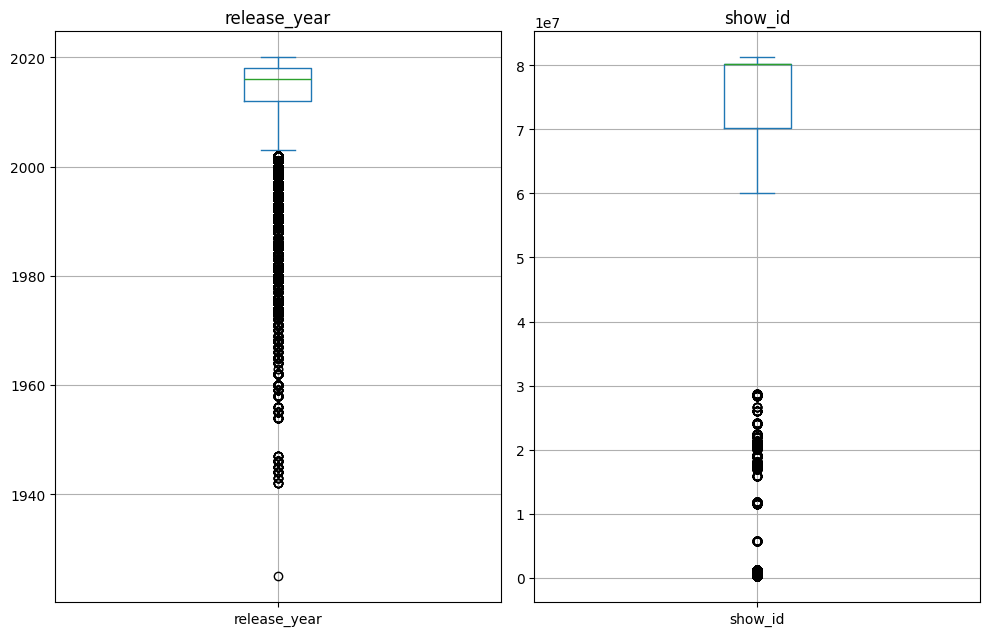

In [53]:
plt.figure(figsize=(10,55))
for i, col in enumerate(num_cols,1):
  plt.subplot(9,2,i)
  merged_df[col].plot(kind = 'box')
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [56]:
Q1 = merged_df[num_cols].quantile(0.25)

Q3 = merged_df[num_cols].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3+ (1.5 * IQR)
lower_limit = Q1- (1.5 * IQR)

outliers = ((merged_df[num_cols] > upper_limit)|(merged_df[num_cols] < lower_limit)).any(axis = 1)

outliers_df = merged_df[outliers]
outlier_percentage = len(outliers_df)* 100/len(merged_df)

print('percentage of outliers in the dataframe: ', outlier_percentage)

percentage of outliers in the dataframe:  8.952383677674126


In [58]:
#clipping is done to avaoid data leakage
merged_df[num_cols] = merged_df[num_cols].clip(lower_limit, upper_limit, axis=1)

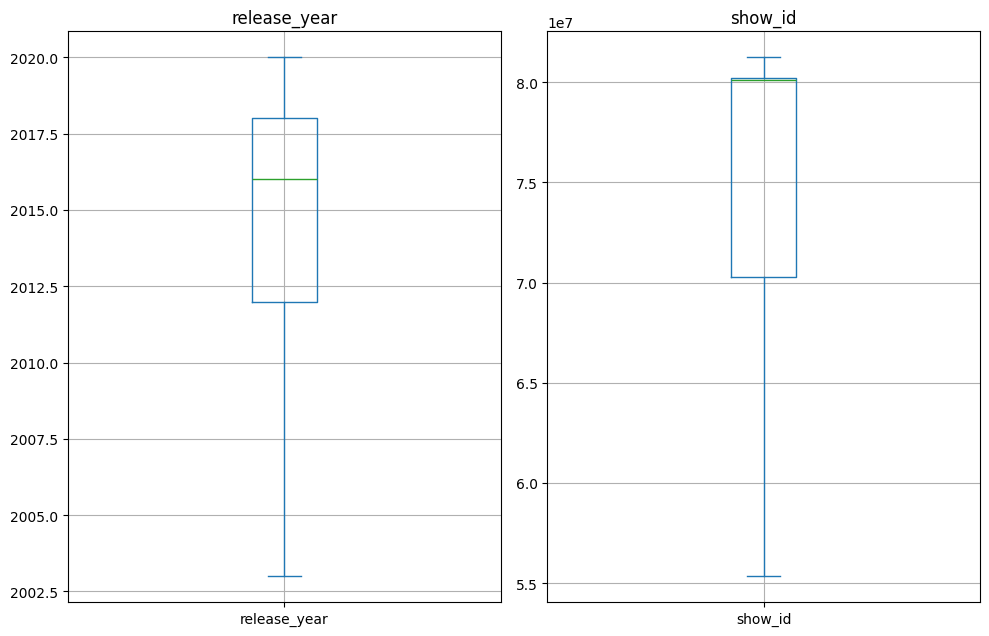

In [59]:
plt.figure(figsize=(10,55))
for i, col in enumerate(num_cols,1):
  plt.subplot(9,2,i)
  merged_df[col].plot(kind = 'box')
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

#Advanced Data Transformation
Workflow: The cast and listed_in (category) columns contain multiple values in a single string (e.g., "Tom Hanks, Tim Allen"). This format is difficult to analyze directly. Select one of these columns (cast or listed_in) and "explode" it, so that each actor or category for a given show gets its own row. Analytical Question: In a markdown cell, explain a business advantage of transforming the data this way. What kind of analysis is possible now that wasn't before (e.g., finding the most frequent actor or genre)? Screenshot Requirement: Upload a screenshot showing your code for the "explode" transformation and your markdown answer.

In [68]:

# Split category column
merged_df["listed_in"] = merged_df["listed_in"].str.split(",")

# Explode
master_category = merged_df.explode("listed_in")

# Remove spaces
master_category["listed_in"] = master_category["listed_in"].str.strip()

print(master_category.head())

   duration_minutes  duration_seasons   type  \
0                90                 1  Movie   
1                90                 1  Movie   
2                90                 1  Movie   
3                90                 1  Movie   
4                90                 1  Movie   

                                     title date_added  release_year rating  \
0  Norm of the North: King Sized Adventure 2019-09-09        2019.0  TV-PG   
1  Norm of the North: King Sized Adventure 2019-09-09        2019.0  TV-PG   
2  Norm of the North: King Sized Adventure 2019-09-09        2019.0  TV-PG   
3  Norm of the North: King Sized Adventure 2019-09-09        2019.0  TV-PG   
4  Norm of the North: King Sized Adventure 2019-09-09        2019.0  TV-PG   

                                         description     show_id  cast  \
0  Before planning an awesome wedding for his gra...  81145628.0   NaN   
1  Before planning an awesome wedding for his gra...  81145628.0   NaN   
2  Before planning a

## Exploding the Data

I selected the listed in column and transformed it using the **explode()** function.

Originally, multiple values were stored in a single cell, making it difficult to analyze individual actors.

After exploding the column, each actor has a separate row for each Netflix title they appear in.

- Analyze collaborations between actors.
- Build actor popularity dashboards.
- Recommend content based on actor preferences.

This transformation converts one-to-many relationships into an analysis-friendly format, making aggregation, filtering, and visualization much easier.


In [75]:
#correlation
corr_matrix = merged_df[num_cols].corr(method ='pearson')
corr_matrix

,release_year,show_id
release_year,1.000000,0.772535
show_id,0.772535,1.000000


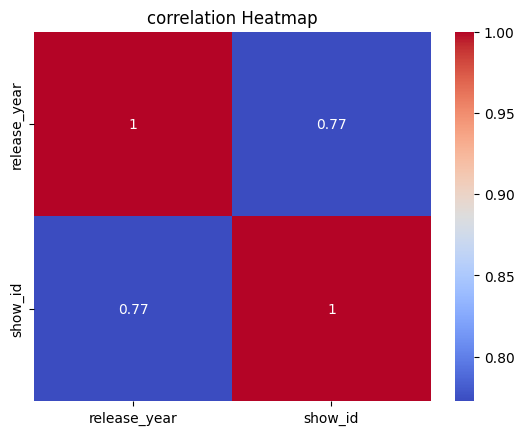

In [76]:
#plotting a heat map to visualise correlation
sns.heatmap(corr_matrix, annot=True,cmap = 'coolwarm')
plt.title("correlation Heatmap")
plt.show()

DATA TRANSFORMATION

##Encoding

In [80]:
#onehot encoding is done
cols =['rating']
merged_df = pd.get_dummies(merged_df, columns=cols, drop_first=True, dtype=int)

In [82]:
merged_df.head()

,duration_minutes,duration_seasons,type,title,date_added,release_year,description,show_id,cast,country,...,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,90,1,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,Before planning an awesome wedding for his gra...,81145628.0,NaN,United States,...,0,0,0,0,0,1,0,0,0,0
1,90,1,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,Before planning an awesome wedding for his gra...,81145628.0,NaN,United States,...,0,0,0,0,0,1,0,0,0,0
2,90,1,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,Before planning an awesome wedding for his gra...,81145628.0,NaN,United States,...,0,0,0,0,0,1,0,0,0,0
3,90,1,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,Before planning an awesome wedding for his gra...,81145628.0,NaN,United States,...,0,0,0,0,0,1,0,0,0,0
4,90,1,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,Before planning an awesome wedding for his gra...,81145628.0,NaN,China,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
X_train = training.drop('Churn', axis=1)
y_train = training['Churn']

#Exploratory Data Analysis
Workflow: Save your final, cleaned DataFrame to a CSV file. Create the app.py file. The main route should load the CSV, perform a few key data aggregations (e.g., value_counts() for top directors, top countries), and pass these results to the template. Screenshot Requirement: Upload two separate screenshots: completed main route (/) within your app.py file

In [81]:

# Save the cleaned DataFrame as CSV
merged_df.to_csv("netflix_cleaned.csv", index=False)

print("CSV saved successfully!")

CSV saved successfully!


TRAIN-TEST

In [87]:
merged_df.head()

,duration_minutes,duration_seasons,type,title,date_added,release_year,description,show_id,cast,country,...,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,90,1,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,Before planning an awesome wedding for his gra...,81145628.0,NaN,United States,...,0,0,0,0,0,1,0,0,0,0
1,90,1,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,Before planning an awesome wedding for his gra...,81145628.0,NaN,United States,...,0,0,0,0,0,1,0,0,0,0
2,90,1,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,Before planning an awesome wedding for his gra...,81145628.0,NaN,United States,...,0,0,0,0,0,1,0,0,0,0
3,90,1,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,Before planning an awesome wedding for his gra...,81145628.0,NaN,United States,...,0,0,0,0,0,1,0,0,0,0
4,90,1,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,Before planning an awesome wedding for his gra...,81145628.0,NaN,China,...,0,0,0,0,0,1,0,0,0,0


In [88]:
##Target
X = merged_df.drop('show_id', axis=1)
y = merged_df['show_id']


In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test data
    random_state=42     # for reproducibility
)

#Model Building:

In [91]:

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline